# 📝 Model Evaluation
This ipython notebook focuses on choosing the best model for predicting the value of calories burnt with the given data.

In [1]:
# Importing necessary libraries and functions

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import root_mean_squared_error, mean_absolute_error, r2_score

In [2]:
# Importing and splitting dataset

df = pd.read_csv("data_without_outliers.csv", index_col=0)
X = df.drop(columns=["Calories"])
y = df["Calories"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [3]:
# Building model pipeline

models = {
    "LinearRegression": LinearRegression(),

    "DecisionTree": DecisionTreeRegressor(
        max_depth=12,
        min_samples_leaf=10,
        random_state=42
    ),

    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        max_depth=20,
        min_samples_leaf=5,
        n_jobs=-1,
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="reg:squarederror",
        random_state=42
    )
}



Training LinearRegression...


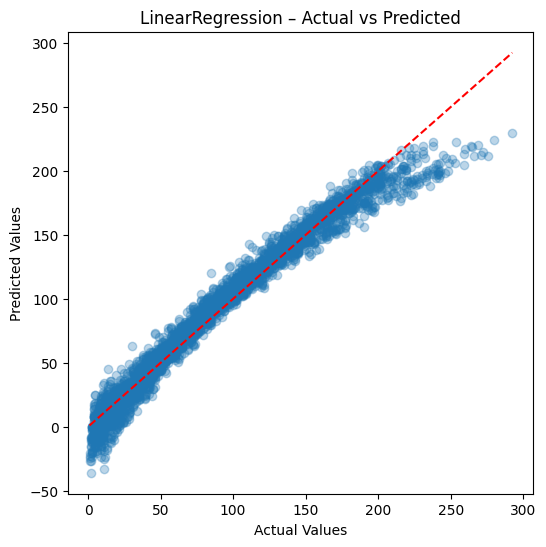


Training DecisionTree...


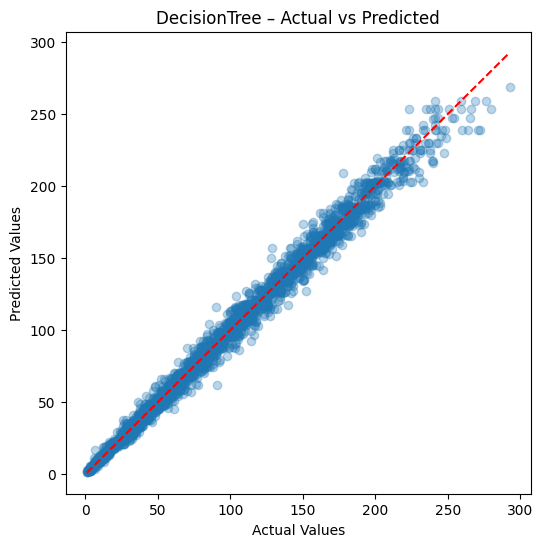


Training RandomForest...


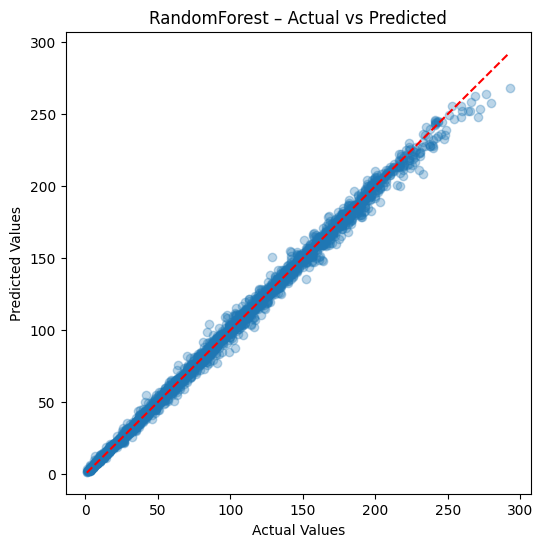


Training XGBoost...


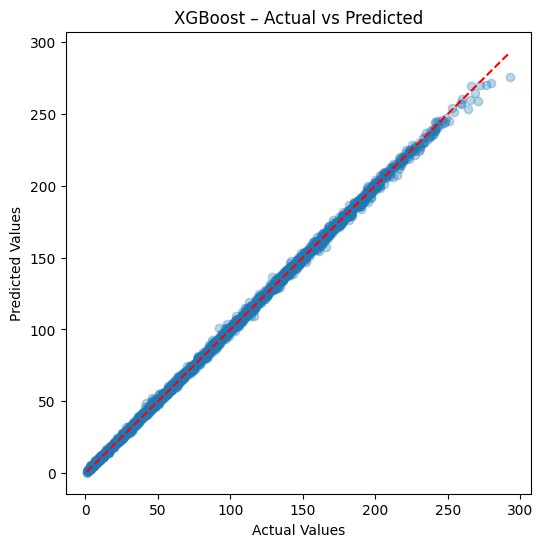

In [4]:
# Training and evaluating models

results = {}

for name, model in models.items():
    print(f"\nTraining {name}...")

    # Contructing pipeline
    pipeline = Pipeline([
        ("scaler", StandardScaler()),
        ("model", model)
    ])

    # Cross-Validation (RMSE)
    cv_rmse = -1 * cross_val_score(
        pipeline, X_train, y_train,
        scoring="neg_root_mean_squared_error",
        cv=5
    ).mean()

    # Train
    pipeline.fit(X_train, y_train)

    # Predict
    y_pred = pipeline.predict(X_test)

    # Metrics
    rmse = root_mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    # Store results
    results[name] = {
        "CV_RMSE": cv_rmse,
        "RMSE": rmse,
        "MAE": mae,
        "R2": r2,
        "y_pred": y_pred
    }

    # Plot Actual vs Predicted
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test, y_pred, alpha=0.3)
    plt.plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             "r--")
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"{name} – Actual vs Predicted")
    plt.show()

In [5]:
# Final Error Report (Markdown Ready)

for name, metrics in results.items():
    print(f"""
>## {name}
>- Cross-Validation RMSE: {metrics['CV_RMSE']:.4f}
>- Test RMSE: {metrics['RMSE']:.4f}
>- Mean Absolute Error (MAE): {metrics['MAE']:.4f}
>- R² Score: {metrics['R2']:.4f}
""")


>## LinearRegression
>- Cross-Validation RMSE: 11.2820
>- Test RMSE: 11.5053
>- Mean Absolute Error (MAE): 8.4267
>- R² Score: 0.9667


>## DecisionTree
>- Cross-Validation RMSE: 6.1654
>- Test RMSE: 5.8019
>- Mean Absolute Error (MAE): 3.9637
>- R² Score: 0.9915


>## RandomForest
>- Cross-Validation RMSE: 3.6617
>- Test RMSE: 3.3983
>- Mean Absolute Error (MAE): 2.1617
>- R² Score: 0.9971


>## XGBoost
>- Cross-Validation RMSE: 1.6715
>- Test RMSE: 1.5587
>- Mean Absolute Error (MAE): 1.0861
>- R² Score: 0.9994



# ⚖️ **ML Model Comparison (Calories Dataset)**
>## A) Linear Regression
>- Cross-Validation RMSE: 11.2820
>- Test RMSE: 11.5053
>- Mean Absolute Error (MAE): 8.4267
>- R² Score: 0.9667


>## B) Decision Tree Regressor
>- Cross-Validation RMSE: 6.1654
>- Test RMSE: 5.8019
>- Mean Absolute Error (MAE): 3.9637
>- R² Score: 0.9915


>## C) Random Forest Regressor
>- Cross-Validation RMSE: 3.6617
>- Test RMSE: 3.3983
>- Mean Absolute Error (MAE): 2.1617
>- R² Score: 0.9971


>## D) XGBoost Regressor
>- Cross-Validation RMSE: 1.6715
>- Test RMSE: 1.5587
>- Mean Absolute Error (MAE): 1.0861
>- R² Score: 0.9994

# 🚀 **CONCLUSION**
The accuracy of the output results are considered good if:
- **RMSE** has a lower value,
- **MAE** has a lower value and,
- **R²** has a higher value.

Hence, the **XGBoost** model outperforms the other ML models with a lower RMSE and MAE and a higher R², indicating better predictive accuracy.
Therefore we will use XGBoost Regressor in training our final model.